# Template de Projet Data - Exploration et Analyse
Ce notebook sert de structure de base pour tout projet d'exploration de données (EDA).

## 1. Importation des librairies et configuration

In [39]:
import pandas as pd
import numpy as np

# Pour les graphiques
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.express as px

# Pour la standardisation des données et la PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Pour l'évaluation des clusters avec la méthode du coude 
from sklearn.cluster import KMeans

# Pour l'évaluation des clusters avec le score de silhouette
from sklearn.metrics import silhouette_score

# Pour les dendrogrammes
from scipy.cluster.hierarchy import dendrogram, linkage
import plotly.figure_factory as ff

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 2. Chargement des données

In [40]:
# Charger votre dataset ici
df = pd.read_csv('..\\Data\\Clean\\Final\\DF_Clean.csv')
df.head()

,Zone,Country Code,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Production,Distance en KM,PIB par habitant,Indice de stabilité politique,Population pouvant acheter une alimentation saine (%),Population,Taux de facilité de faire des affaires (%),Cumul Population
0,China,CHN,12.33,18161.0,576.0,452.0,17518.0,18236.0,8225.232,15022.437188,-0.203288,71.8,1421021000,64.20096,1421021000
1,India,IND,2.22,3661.0,4.0,0.0,2965.0,3545.0,6594.230,6144.717144,-0.572111,30.5,1338676000,60.90760,2759697000
2,United States,USA,55.68,18266.0,3692.0,123.0,18100.0,21914.0,5838.157,60047.719073,0.110129,95.0,325084000,83.59008,3084781000
3,Indonesia,IDN,7.19,2323.0,0.0,1.0,1904.0,2301.0,11584.250,10687.640922,-0.581615,49.7,264650000,66.86799,3349431000
4,Pakistan,PAK,5.86,1282.0,4.0,2.0,1218.0,1281.0,5932.586,4789.536466,-2.218410,42.2,207906000,53.01708,3557337000


In [41]:
df['Production / habitant']= df['Production'] / df['Population']
df['Importations / habitant']= df['Importations - Quantité'] / df['Population']
df['TDI — Taux de dépendance aux importations (%)']= df['Importations - Quantité'] / df['Disponibilité intérieure'] * 100

In [42]:
# Exclusion de la France car il s'agit du pays de référence, où se trouve notre entreprise. De ce fait, il n'est pas prévu d'exporter vers la France
df = df[df['Zone'] != 'France']


In [43]:
# Sélection des variables quantitatives actives
variables = [
    'Disponibilité alimentaire en quantité (kg/personne/an)',
    'Importations - Quantité', 
    'Nourriture',
    'Distance en KM',
    'PIB par habitant', 
    'Indice de stabilité politique', 
    'Population pouvant acheter une alimentation saine (%)',
    'Population', 
    'Taux de facilité de faire des affaires (%)',
    'Production / habitant',
    'Importations / habitant',
    'TDI — Taux de dépendance aux importations (%)'
]

### Definition des DF qualitatifs et quantitatifs

In [44]:
info_pays = df[['Zone', 'Country Code']]

# Sélection des variables quantitatives pertinentes pour l'ACP
features = [
    'Disponibilité alimentaire en quantité (kg/personne/an)',
    'Importations - Quantité', 
    'Nourriture',
    'Distance en KM',
    'PIB par habitant', 
    'Indice de stabilité politique', 
    'Population pouvant acheter une alimentation saine (%)',
    'Population', 
    'Taux de facilité de faire des affaires (%)',
    'Production / habitant',
    'Importations / habitant',
    'TDI — Taux de dépendance aux importations (%)']

### Standardisation des données : On centre et reduit les données 

In [45]:
# Instanciation du Scaler et application de la standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

### Matrice de corrélations 

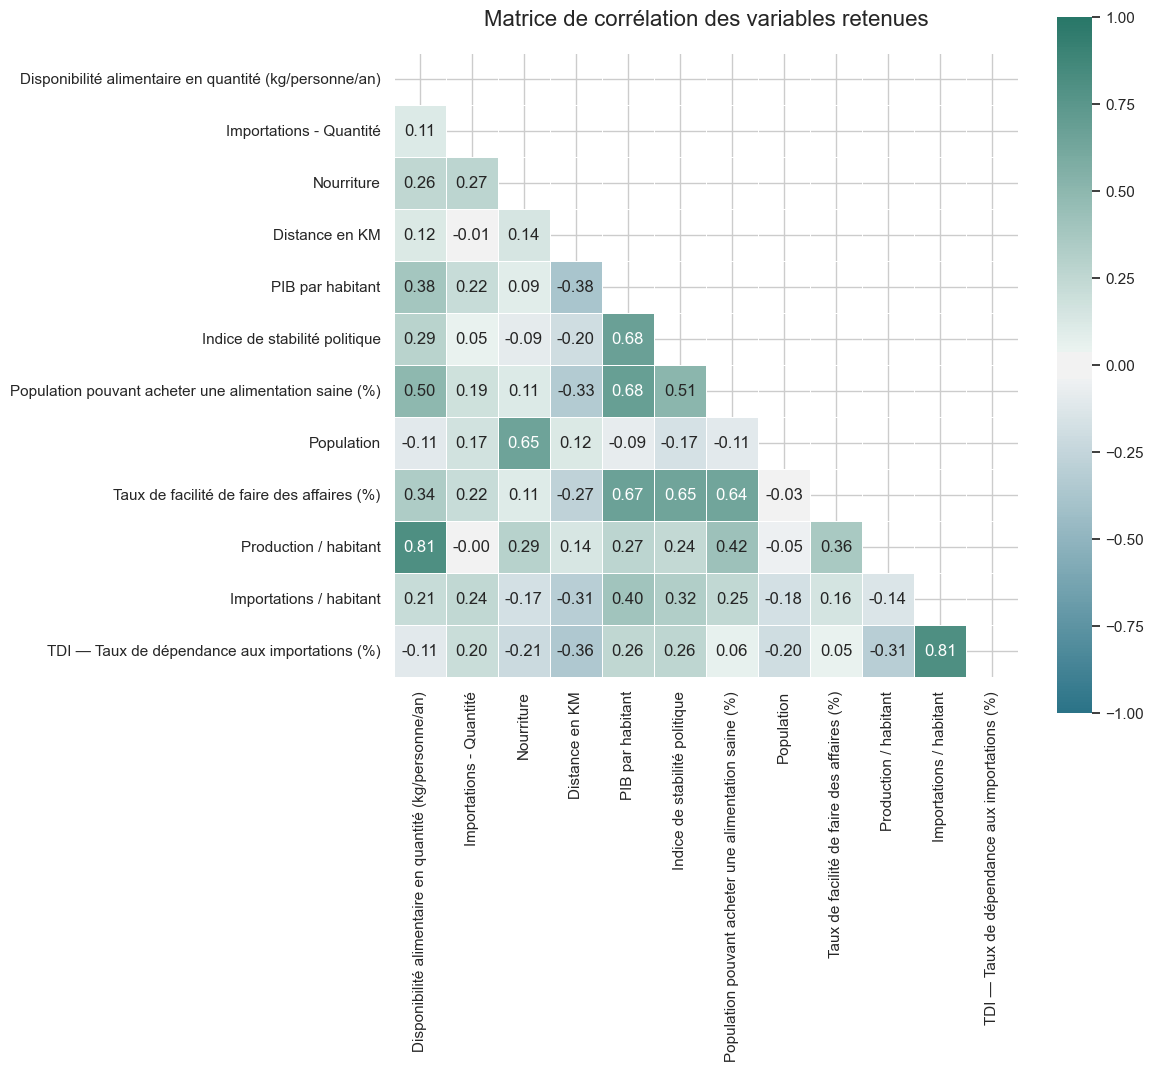

In [46]:
corr_matrix = df[features].corr()

# masque pour n'avoir que la moitié du graphique
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
custom_palette_intense = sns.diverging_palette(220, 170, sep=10, l=45, s=85, as_cmap=True)
# Affichage de la Heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=custom_palette_intense,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    mask=mask,           
    linewidths=0.5,      
    cbar_kws={"shrink": 0.8} 
)

plt.title("Matrice de corrélation des variables retenues", 
        fontsize=16, 
        pad=20)
plt.tight_layout()
plt.show()

### Analyses en Composantes Principales - ACP

In [47]:
pca = PCA(n_components=len(features))
X_projected = pca.fit_transform(X_scaled)

In [48]:
# Calcul des valeurs propres et de la variance expliquée
valeurs_propres = pca.explained_variance_
variance_expliquee = pca.explained_variance_ratio_ * 100

In [49]:
# Éboulis des valeurs propres & Seuil de Kaiser 
print("--- ANALYSE DES VALEURS PROPRES (CRITÈRE DE KAISER) ---")
for i, val in enumerate(valeurs_propres):
    statut = "Retenu (>= 1)" if val >= 1 else "Exclu (< 1)"
    print(f"Composante {i+1} : Valeur propre = {val:.3f} | Variance expliquée = {variance_expliquee[i]:.1f}% | {statut}")

--- ANALYSE DES VALEURS PROPRES (CRITÈRE DE KAISER) ---
Composante 1 : Valeur propre = 3.891 | Variance expliquée = 32.1% | Retenu (>= 1)
Composante 2 : Valeur propre = 2.542 | Variance expliquée = 21.0% | Retenu (>= 1)
Composante 3 : Valeur propre = 1.643 | Variance expliquée = 13.6% | Retenu (>= 1)
Composante 4 : Valeur propre = 1.152 | Variance expliquée = 9.5% | Retenu (>= 1)
Composante 5 : Valeur propre = 0.767 | Variance expliquée = 6.3% | Exclu (< 1)
Composante 6 : Valeur propre = 0.713 | Variance expliquée = 5.9% | Exclu (< 1)
Composante 7 : Valeur propre = 0.361 | Variance expliquée = 3.0% | Exclu (< 1)
Composante 8 : Valeur propre = 0.296 | Variance expliquée = 2.4% | Exclu (< 1)
Composante 9 : Valeur propre = 0.263 | Variance expliquée = 2.2% | Exclu (< 1)
Composante 10 : Valeur propre = 0.238 | Variance expliquée = 2.0% | Exclu (< 1)
Composante 11 : Valeur propre = 0.174 | Variance expliquée = 1.4% | Exclu (< 1)
Composante 12 : Valeur propre = 0.073 | Variance expliquée = 0

In [50]:
variance_cumulee = variance_expliquee.cumsum()
print("\n--- VARIANCE CUMULÉE ---")
for i, var in enumerate(variance_cumulee):
    print(f"Composante {i+1} : Variance cumulée = {var:.1f}%")


--- VARIANCE CUMULÉE ---
Composante 1 : Variance cumulée = 32.1%
Composante 2 : Variance cumulée = 53.1%
Composante 3 : Variance cumulée = 66.7%
Composante 4 : Variance cumulée = 76.2%
Composante 5 : Variance cumulée = 82.5%
Composante 6 : Variance cumulée = 88.4%
Composante 7 : Variance cumulée = 91.4%
Composante 8 : Variance cumulée = 93.8%
Composante 9 : Variance cumulée = 96.0%
Composante 10 : Variance cumulée = 98.0%
Composante 11 : Variance cumulée = 99.4%
Composante 12 : Variance cumulée = 100.0%


In [51]:
fig_eboulis = go.Figure()
fig_eboulis.add_trace(go.Bar(
    x=[f"F{i+1}" for i in range(len(features))], 
    y=valeurs_propres, 
    name="Valeurs propres",
    marker=dict(
        color=valeurs_propres,          
        colorscale='Blugrn',           
        showscale=False)
))
fig_eboulis.add_trace(go.Scatter(
    x=[f"F{i+1}" for i in range(len(features))],
    y=variance_cumulee,
    mode="lines+markers",
    name="Variance cumulée (%)",
    line=dict(color="red", width=2),
    yaxis="y2"
))
# Seuil de Kaiser
fig_eboulis.add_hline(
    y=1, 
    line_dash="dash", 
    line_color="black", 
    annotation_text="Seuil de Kaiser")

fig_eboulis.update_layout(
    template="plotly_white",
    xaxis_title="Composantes principales", 
    yaxis_title="Valeurs propres",
        yaxis2=dict(
        title="Variance cumulée (%)",
        overlaying="y",
        side="right",
        range=[0, 100]
    ),
    title=dict(
        text="Éboulis des valeurs propres",
        x=0.5,               
        xanchor="center",    
        y=0.95,              
        yanchor="top",       
        font=dict(size=20, color="black")),
        )

fig_eboulis.show()

### Cercle de corrélation (F1 et F2)

In [52]:
pcs = pca.components_

In [53]:
pcs = pca.components_
# Coordonnées des variables sur F1 et F2
x_coords = pcs[0, :] * np.sqrt(valeurs_propres[0])
y_coords = pcs[1, :] * np.sqrt(valeurs_propres[1])

fig_cercle_1_2 = go.Figure()
# Dessin du cercle unité (0 à 1)
th = np.linspace(0, 2*np.pi, 100)
fig_cercle_1_2.add_trace(go.Scatter(
    x=np.cos(th), 
    y=np.sin(th), 
    mode="lines", 
    line=dict(
        color="black", 
        width=1), 
        showlegend=False))

# Ajout des vecteurs de chaque variable
for i, var in enumerate(features):
    fig_cercle_1_2.add_trace(go.Scatter(
        x=[0, x_coords[i]], 
        y=[0, y_coords[i]], 
        mode="lines+markers+text",
        text=["", var], 
        textposition="top center", 
        name=var,
        marker=dict(
            size=[0, 8]), 
            line=dict(
                width=2)))

fig_cercle_1_2.update_layout(
    template="plotly_white",
    title=dict(
        text=f"Cercle des corrélations (Composante 1 : {variance_expliquee[0]:.1f}% | Composante 2 : {variance_expliquee[1]:.1f}%)",
        x=0.5,               
        xanchor="center",    
        y=0.95,              
        yanchor="top",       
        font=dict(size=20, color="black")),
    xaxis=dict(
        range=[-1.6, 1.6], 
        constrain="domain"), 
        yaxis=dict(
            scaleanchor="x"),
    width=1200, 
    height=1200,
    legend=dict(
        orientation="h",       
        yanchor="top",         
        y=-0.1,               
        xanchor="center",      
        x=0.5                  
    )
)
fig_cercle_1_2.show()

In [54]:
pcs = pca.components_
# Coordonnées des variables sur F2 et F3
x_coords = pcs[1, :] * np.sqrt(valeurs_propres[1])
y_coords = pcs[2, :] * np.sqrt(valeurs_propres[2])

fig_cercle_1_3 = go.Figure()

th = np.linspace(0, 2*np.pi, 100)
fig_cercle_1_3.add_trace(go.Scatter(
    x=np.cos(th), 
    y=np.sin(th), 
    mode="lines", 
    line=dict(
        color="darkgrey", 
        width=1), 
        showlegend=False))

# Ajout des vecteurs de chaque variable
for i, var in enumerate(features):
    fig_cercle_1_3.add_trace(go.Scatter(
        x=[0, x_coords[i]], y=[0, y_coords[i]], 
        mode="lines+markers+text", 
        text=["", var], 
        textposition="top center", 
        name=var,
        marker=dict(size=[0, 8]), 
        line=dict(width=2)))

fig_cercle_1_3.update_layout(
    template="plotly_white",
    title=dict(
        text=f"Cercle des corrélations (Composante 2 : {variance_expliquee[1]:.1f}% | Composante 3 : {variance_expliquee[2]:.1f}%)",
        x=0.5,               
        xanchor="center",    
        y=0.95,              
        yanchor="top",       
        font=dict(size=20, color="black")),
    xaxis=dict(
        range=[-1.6, 1.6], 
        constrain="domain"), 
        yaxis=dict(
            scaleanchor="x"),
    width=1200, 
    height=1200,
    legend=dict(
        orientation="h",       
        yanchor="top",         
        y=-0.1,               
        xanchor="center",      
        x=0.5                  
    )
)
fig_cercle_1_3.show()

###  Détermination du nombre de clusters à retenir 

### Plusieurs solutions nous permettent de définir le nombre de cluster à retenir
* Le K-Means
* L'arbre de décision (CAH) 
* Le score Silhouette

#### Algorithme KMeans

In [55]:
list_inertie=[]
k_list = list(range(2, 7))

for k in k_list:
    kmeans= KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    list_inertie.append(kmeans.inertia_)

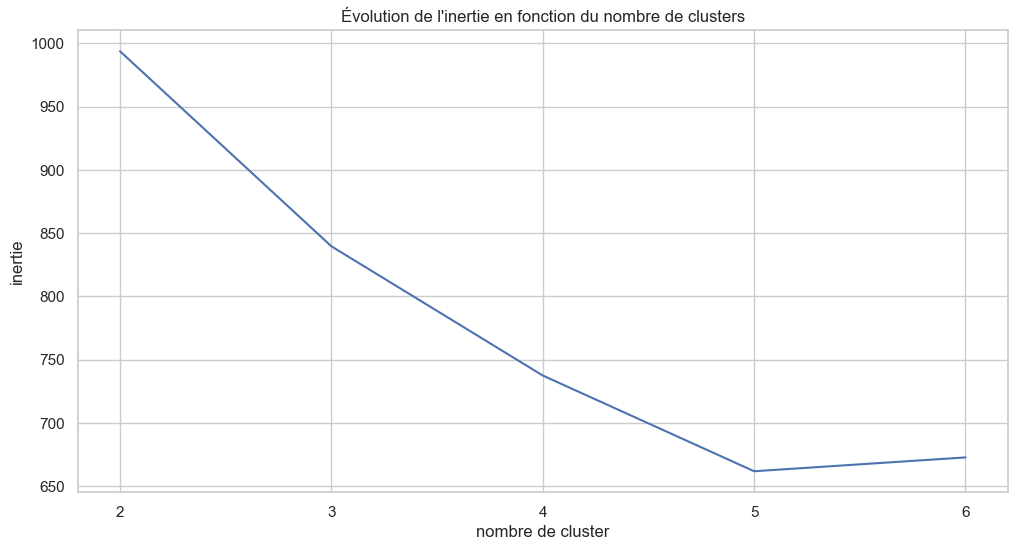

In [56]:
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("inertie")
ax.set_xlabel("nombre de cluster")
ax.set_xticks(k_list)
ax.set_title("Évolution de l'inertie en fonction du nombre de clusters")
ax = plt.plot(k_list, list_inertie)

### Partition des données avec le CAH (Classification Ascendante Hiérarchique)
Arbre de décision (dendrograme)
On ne calcule pas l'inertie du nuage de points tout entier mais celle des différents nuages correspondant à chaque groupe : on calcule l'inertie propre à chaque cluster et on prend la moyenne des valeurs.
Utilisation de la méthode de Ward : correspond à la distance entre les cluster
On cherche à définir le nombre de cluster optimal. 
On parle de l'algorithme des centres mobiles en français. 
On va chercher à minimiser l'inertie intraclasse et maximiser l'inertie interclasse

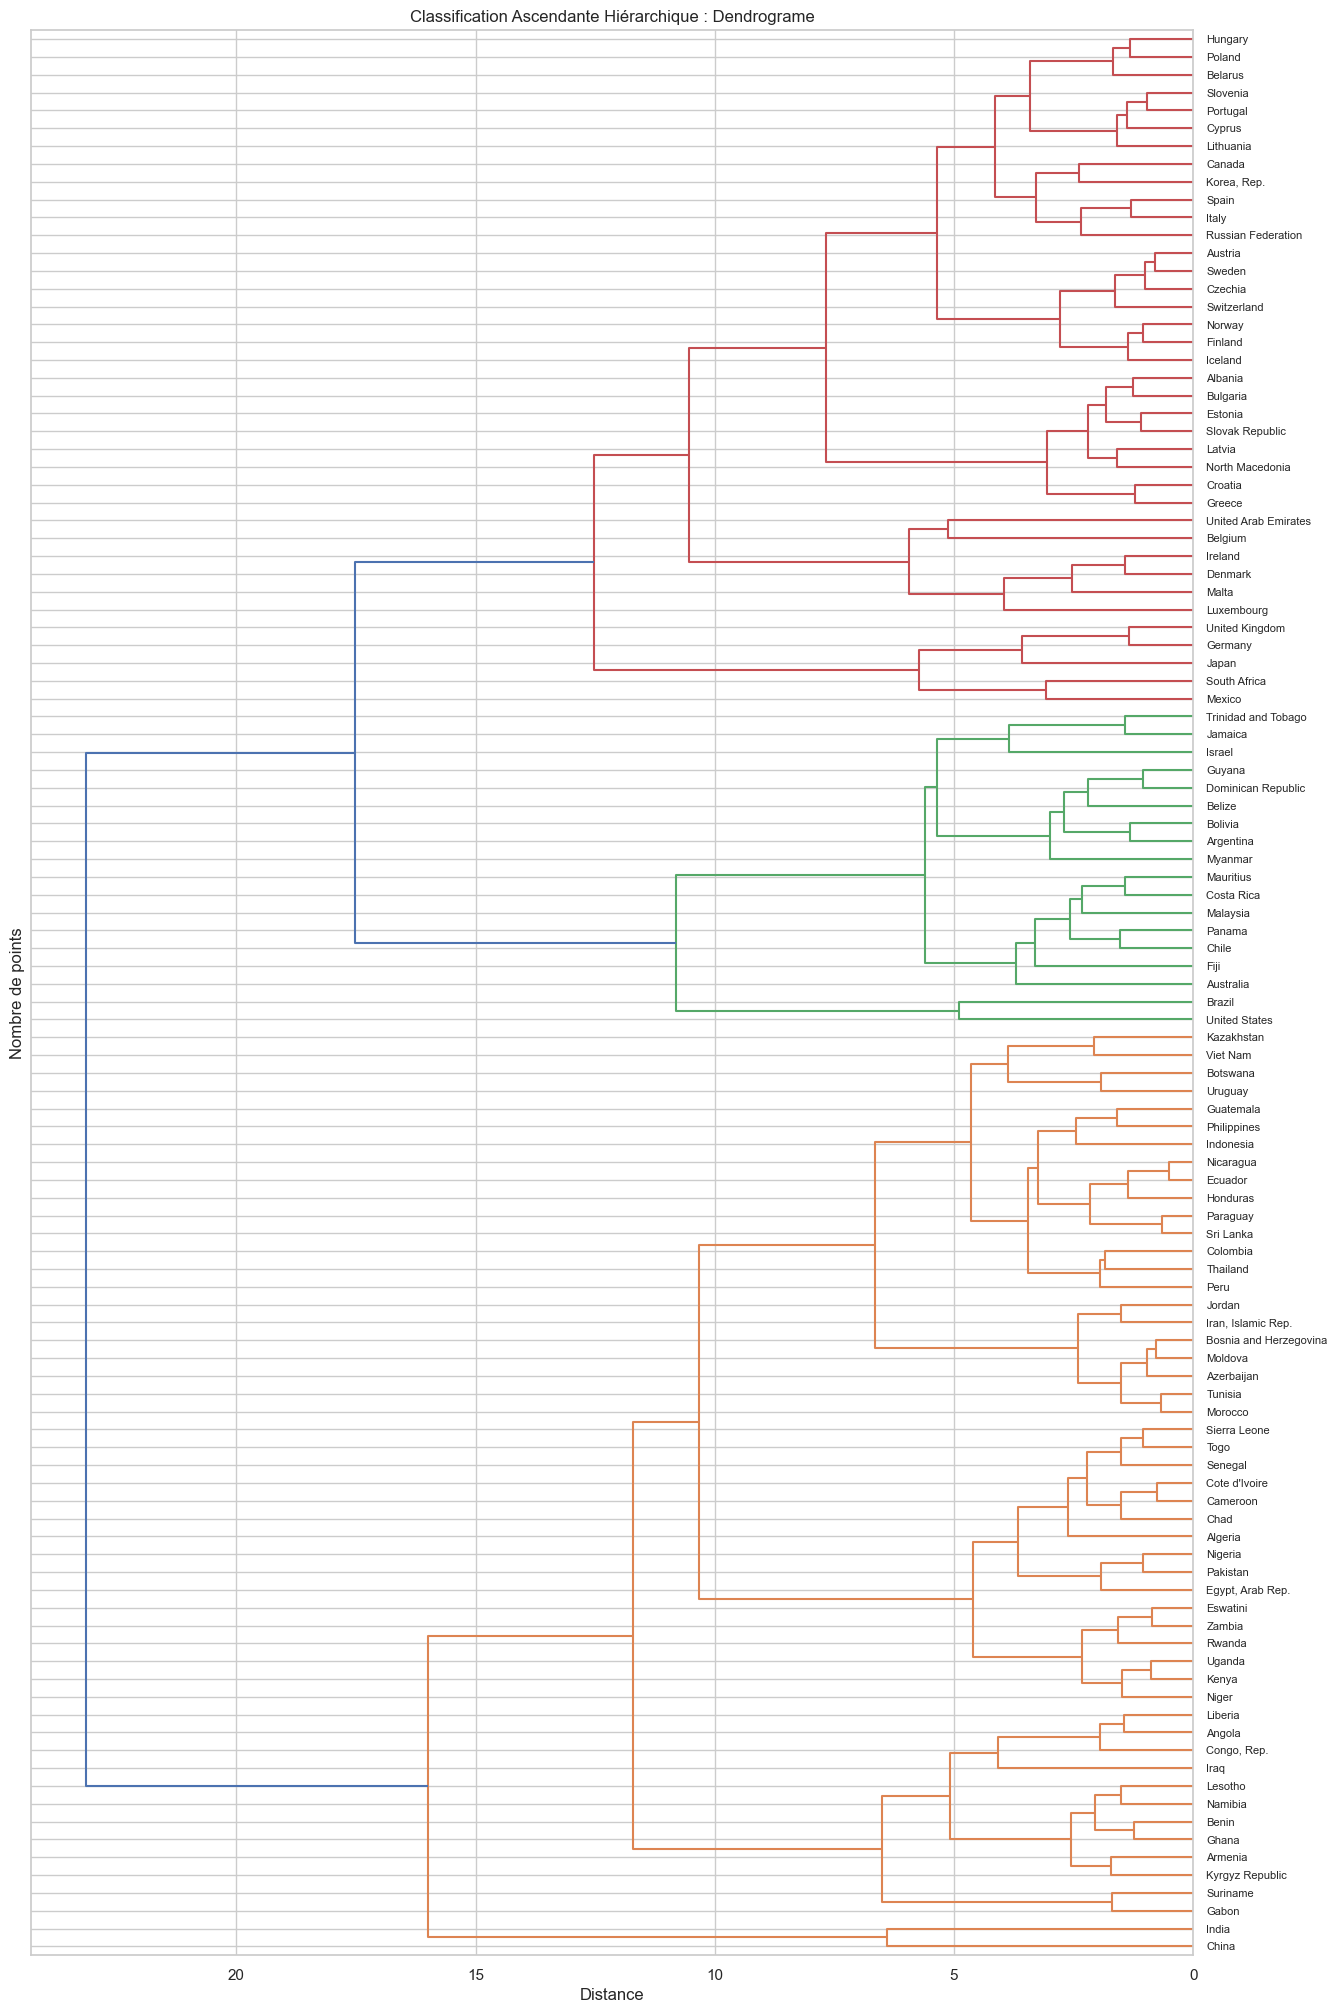

In [57]:
Z = linkage(X_scaled, method="ward")
fig, ax = plt.subplots(1, 1, figsize=(15, 25))

_ = dendrogram(
    Z, 
    ax=ax,
    orientation='left',
    labels=df['Zone'].values,
    leaf_font_size=8)

plt.title("Classification Ascendante Hiérarchique : Dendrograme")
plt.ylabel("Nombre de points")
plt.xlabel("Distance")
plt.show()

#### Le Score Silouhette
Il faut au minimum 2 clusters pour que le score de silhouette soit calculable, et au maximum 6 clusters pour éviter d'avoir des groupes trop petits et peu interprétables.

In [58]:

k_list = list(range(2, 7))
scores_silhouette = []

for k in k_list:
    kmeans= KMeans(n_clusters=k)
    labels_test = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_test)
    scores_silhouette.append(score)
    print(f"Pour K = {k}, le score de Silhouette est de : {score:.3f}")

fig_silh = px.line(
    x=k_list, 
    y=scores_silhouette,
    # title="Évolution du score de Silhouette",
    labels={
        'x': 'Nombre de clusters (K)', 
        'y': 'Score de Silhouette'})
fig_silh.update_layout(
    template="plotly_white",
    xaxis_type='category',
    legend=dict(
        orientation="h",
        xanchor="center",
        x=0.35,
        maxheight=0.35,
        title_text="Country"
    ),
    title=dict(
        text="Évolution du score de Silhouette",
        x=0.5,               
        xanchor="center",    
        y=0.95,              
        yanchor="top",       
        font=dict(size=20, color="black")))
fig_silh.show()

Pour K = 2, le score de Silhouette est de : 0.235
Pour K = 3, le score de Silhouette est de : 0.225
Pour K = 4, le score de Silhouette est de : 0.186
Pour K = 5, le score de Silhouette est de : 0.204
Pour K = 6, le score de Silhouette est de : 0.234


### Nombre de clusters retenus


* On peut hésiter entre 4 et 5 clusters
* On peut hésiter entre 4 et 5 clusters principalement
* Le point le plus haut (le score de Silhouette le plus proche de 1) est celui à retenir : entre 3 et 4

* #### On part donc sur une étude basée sur 4 clusters.

### Test du nombre de clusters à retenir entre 3, 4 et 5

#### 3 CLUSTERS

In [59]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster3'] = kmeans.fit_predict(X_scaled)

In [60]:
df['KCluster3'] = df['Cluster3'].astype(str)

In [70]:
df['F1'] = X_projected[:, 0]
df['F2'] = X_projected[:, 1]

fig_projection3 = px.scatter(
    df, 
    x='F1', 
    y='F2', 
    color='KCluster3', 
    hover_name='Zone',
    text='Zone', 
    labels={'F1': f'Composante 1 ({variance_expliquee[0]:.1f}%)', 'F2': f'Composante 2 ({variance_expliquee[1]:.1f}%)'},
    template='plotly_white')
fig_projection3.update_layout(
    width=1400,
    height=850,
    title={
        'text': "Projection des individus sur le plan factoriel F1 / F2 (3 Clusters)",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
        },
    legend=dict(
        orientation="h",
        xanchor="center",
        x=0.2,
        maxheight=0.35,
        title_text=""
    ),
    margin=dict(l=50, r=50, b=50, t=100))
fig_projection3.update_traces(textposition='top center')
fig_projection3.show()

#### 4 CLUSTERS

In [62]:
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster4'] = kmeans4.fit_predict(X_scaled)


### Projection des individus (Pays) selon les composantes 1 et 2

In [63]:
df['KCluster4'] = df['Cluster4'].astype(str)

In [ ]:
df['F1'] = X_projected[:, 0]
df['F2'] = X_projected[:, 1]

fig_projection = px.scatter(
    df, 
    x='F1', 
    y='F2', 
    color='KCluster4', 
    hover_name='Zone',
    text='Zone', 
    labels={'F1': f'Composante 1 ({variance_expliquee[0]:.1f}%)', 'F2': f'Composante 2 ({variance_expliquee[1]:.1f}%)'},
    template='plotly_white')
fig_projection.update_layout(
    width=1400,
    height=850,
    title={
        'text': "Projection des individus sur le plan factoriel F1 / F2 (4 Clusters)",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
        },
    legend=dict(
        orientation="h",
        xanchor="center",
        x=0.2,
        maxheight=0.35,
        title_text=""
    ),
    margin=dict(l=50, r=50, b=50, t=100))
fig_projection.update_traces(textposition='top center')
fig_projection.show()

### 5 CLUSTERS

In [65]:
kmeans5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster5'] = kmeans5.fit_predict(X_scaled)


In [66]:
df['KCluster5'] = df['Cluster5'].astype(str)

In [71]:
df['F1'] = X_projected[:, 0]
df['F2'] = X_projected[:, 1]

fig_projection = px.scatter(
    df, 
    x='F1', 
    y='F2', 
    color='KCluster5', 
    hover_name='Zone',
    text='Zone', 
    labels={'F1': f'Composante 1 ({variance_expliquee[0]:.1f}%)', 'F2': f'Composante 2 ({variance_expliquee[1]:.1f}%)'},
    template='plotly_white')
fig_projection.update_layout(
    width=1400,
    height=850,
    title={
        'text': "Projection des individus sur le plan factoriel F1 / F2 (5 Clusters)",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
        },
    legend=dict(
        orientation="h",
        xanchor="center",
        x=0.2,
        maxheight=0.35,
        title_text=""
    ),
    margin=dict(l=50, r=50, b=50, t=100))
fig_projection.update_traces(textposition='top center')
fig_projection.show()

### Analyse et Sélection des marchés prioritaires

In [72]:
print("\n CARACTÉRISTIQUES MOYENNES DES CLUSTERS ")
profils = df.groupby('Cluster4')[features].mean()
display(profils.T)


 CARACTÉRISTIQUES MOYENNES DES CLUSTERS 


Cluster4,0,1,2,3
Disponibilité alimentaire en quantité (kg/personne/an),3.031081e+01,2.282200e+01,7.913333e+00,2.341000e+01
Importations - Quantité,7.578378e+01,1.588286e+02,5.578788e+01,1.916667e+02
Nourriture,1.052757e+03,4.058571e+02,2.749697e+02,1.286100e+04
Distance en KM,7.403161e+03,2.415861e+03,6.260869e+03,6.885873e+03
PIB par habitant,1.826368e+04,4.307716e+04,6.516061e+03,2.707162e+04
Indice de stabilité politique,-8.064988e-02,6.796137e-01,-6.304817e-01,-2.217567e-01
Population pouvant acheter une alimentation saine (%),7.688378e+01,8.964286e+01,4.240606e+01,6.576667e+01
Population,3.340135e+07,1.788717e+07,4.035294e+07,1.028260e+09
Taux de facilité de faire des affaires (%),6.587665e+01,7.515639e+01,5.499176e+01,6.956621e+01
Production / habitant,3.550444e-05,1.931777e-05,4.625094e-06,2.763048e-05


In [73]:
# # Définition d'un dictionnaire pour nommer les clusters de manière plus parlante
noms_clusters = {
    0: "Cluster 0 : Marchés à faible dépendance aux importations et assez éloignés géographiquement",
    1: "Cluster 1 : Marchés Cibles (Économies riches, stables, et avec un fort pouvoir d'achat)",
    2: "Cluster 2 : Zones à faible pouvoir d'achat et relativement instable politiquement",
    3: "Cluster 3 : Géants démographiques (concurrence accrue) et éloignés géographiquement",
}

df['KCluster4'] = df['Cluster4'].map(noms_clusters)

df['F1'] = X_projected[:, 0]
df['F2'] = X_projected[:, 1]

fig_projection_categ = px.scatter(
    df, 
    x='F1', 
    y='F2', 
    color='KCluster4', 
    hover_name='Zone',
    text='Zone',
    template='plotly_white')
fig_projection_categ.update_layout(
    width=1400,
    height=850,
    title={
        'text': "Projection des individus selon les composantes 1 et 2",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
        },
    xaxis=dict(
        title=f"Composante 1 ({variance_expliquee[0]:.1f}%)",
        zeroline=True, zerolinewidth=2, zerolinecolor='LightGrey', 
        showgrid=True,
        gridcolor='whitesmoke'
    ),
    yaxis=dict(
        title=f"Composante 2 ({variance_expliquee[1]:.1f}%)",
        zeroline=True, zerolinewidth=2, zerolinecolor='LightGrey', 
        showgrid=True,
        gridcolor='whitesmoke'
    ),
    legend=dict(
        orientation="h",
        xanchor="center",
        x=0.2,
        maxheight=0.35,
        title_text=""
    ),
    margin=dict(l=50, r=50, b=50, t=100)
)
fig_projection_categ.show()

### Définition du marché cible

In [74]:
print("SYNTHÈSE DES FORCES PAR CLUSTER")
for num_cluster, nom_complet in noms_clusters.items():
    print(f"\n{nom_complet}")
    moyennes_cluster = profils.loc[num_cluster]
    
    # Présentations d'une synthèse
    print(f"Pouvoir d'achat (PIB/hab) : {moyennes_cluster['PIB par habitant']:.0f} $")
    print(f"Volume d'importations volailles : {moyennes_cluster['Importations - Quantité']:.0f} kt")
    print(f"Score de Stabilité Politique : {moyennes_cluster['Indice de stabilité politique']:.2f}")
    print(f"Distance depuis la France : {moyennes_cluster['Distance en KM']:.0f} KM")

SYNTHÈSE DES FORCES PAR CLUSTER

Cluster 0 : Marchés à faible dépendance aux importations et assez éloignés géographiquement
Pouvoir d'achat (PIB/hab) : 18264 $
Volume d'importations volailles : 76 kt
Score de Stabilité Politique : -0.08
Distance depuis la France : 7403 KM

Cluster 1 : Marchés Cibles (Économies riches, stables, et avec un fort pouvoir d'achat)
Pouvoir d'achat (PIB/hab) : 43077 $
Volume d'importations volailles : 159 kt
Score de Stabilité Politique : 0.68
Distance depuis la France : 2416 KM

Cluster 2 : Zones à faible pouvoir d'achat et relativement instable politiquement
Pouvoir d'achat (PIB/hab) : 6516 $
Volume d'importations volailles : 56 kt
Score de Stabilité Politique : -0.63
Distance depuis la France : 6261 KM

Cluster 3 : Géants démographiques (concurrence accrue) et éloignés géographiquement
Pouvoir d'achat (PIB/hab) : 27072 $
Volume d'importations volailles : 192 kt
Score de Stabilité Politique : -0.22
Distance depuis la France : 6886 KM


In [76]:
CLUSTER_CIBLE = 1
df_cible = df[df['Cluster4'] == CLUSTER_CIBLE]

# Extraction du Top 5
top10 = df_cible.sort_values(by='PIB par habitant', ascending=False).head(10)

print("\n--- RECOMMANDATION STRATÉGIQUE : TOP 10 PAYS PRIORITAIRES ---")
print(top10[['Zone', 'PIB par habitant', 'Importations / habitant', 'Distance en KM','Indice de stabilité politique']])


--- RECOMMANDATION STRATÉGIQUE : TOP 10 PAYS PRIORITAIRES ---
                     Zone  PIB par habitant  Importations / habitant  \
104            Luxembourg     114985.842236             1.861252e-05   
79                Ireland      80450.352934             2.082895e-05   
61   United Arab Emirates      70281.888950             4.564140e-05   
65            Switzerland      68193.505594             6.031934e-06   
76                 Norway      64589.555920             3.776435e-07   
108               Iceland      55638.492059             5.988024e-06   
73                Denmark      55271.597600             2.320307e-05   
13                Germany      54110.253665             1.018655e-05   
64                Austria      53869.832118             1.247307e-05   
57                 Sweden      51474.119912             8.481422e-06   

     Distance en KM  Indice de stabilité politique  
104        289.1023                       1.271542  
79         778.2031                   

In [77]:
top10['Rang'] = range(1, 11)
top10 = top10.sort_values(by='Importations - Quantité', ascending=False)
fig_top10 = px.bar(
    top10.iloc[::-1], 
    x='Importations - Quantité',
    y='Zone',
    orientation='h', 
    title="Top 10 des pays cibles pour l'exportation de volaille",
    text='Importations - Quantité', 
    labels={'Importations - Quantité': 'Importations de volaille (kt)', 
            'Zone': 'Pays Cibles'},
    color='Importations - Quantité',
    color_continuous_scale='Blugrn',
    template='plotly_white')
fig_top10.update_traces(
    texttemplate='%{text:.0f} kt',
    textposition='outside')

fig_top10.update_layout(
    title=dict(
        x=0.5,               
        xanchor="center",   
        y=0.95,             
        yanchor="top",       
        font=dict(
            size=16, 
            color="black")),
    showlegend=False,
    coloraxis_showscale=False, 
    width=1200,
    height=900)

fig_top10.show()

In [ ]:
top10

,Zone,Country Code,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Production,Distance en KM,PIB par habitant,Indice de stabilité politique,Population pouvant acheter une alimentation saine (%),Population,Taux de facilité de faire des affaires (%),Cumul Population,Production / habitant,Importations / habitant,TDI — Taux de dépendance aux importations (%),Cluster,Nom_Cluster,F1,F2,Rang
13,Germany,DEU,19.47,1739.0,646.0,842.0,1609.0,1514.0,439.8984,54110.253665,0.702224,97.3,82658000,79.34962,4998808000,0.000018,1.018655e-05,48.418631,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",2.901063,0.505046,8
61,United Arab Emirates,ARE,43.47,412.0,94.0,433.0,412.0,48.0,5249.5350,70281.888950,0.719287,96.8,9487000,79.30036,7069435000,0.000005,4.564140e-05,105.097087,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",4.423509,2.557132,3
73,Denmark,DNK,28.98,167.0,139.0,133.0,166.0,173.0,1027.6090,55271.597600,0.914903,99.1,5732000,84.58060,7212223000,0.000030,2.320307e-05,79.640719,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",3.610756,1.307038,7
64,Austria,AUT,18.20,173.0,78.0,110.0,160.0,148.0,1035.1440,53869.832118,0.926696,97.5,8819000,78.70694,7114842000,0.000017,1.247307e-05,63.583815,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",2.513799,1.247324,9
79,Ireland,IRL,25.82,128.0,93.0,99.0,123.0,110.0,778.2031,80450.352934,0.941803,97.7,4753000,80.10187,7243289000,0.000023,2.082895e-05,77.343750,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",3.742668,1.523360,2
57,Sweden,SWE,16.60,187.0,23.0,84.0,164.0,157.0,1545.7970,51474.119912,0.866892,96.5,9904000,82.17491,7030589000,0.000016,8.481422e-06,44.919786,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",2.227100,0.819285,10
65,Switzerland,CHE,15.72,133.0,4.0,51.0,133.0,91.0,436.0778,68193.505594,1.164157,98.7,8455000,76.60784,7123297000,0.000011,6.031934e-06,38.345865,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",2.435012,0.948068,4
104,Luxembourg,LUX,18.33,11.0,1.0,11.0,11.0,0.0,289.1023,114985.842236,1.271542,97.4,591000,69.58844,7339636000,0.000000,1.861252e-05,100.000000,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",3.822771,2.675251,1
108,Iceland,ISL,29.95,10.0,0.0,2.0,10.0,10.0,2234.7230,55638.492059,1.250357,99.4,334000,78.99464,7342766000,0.000030,5.988024e-06,20.000000,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",2.655867,-0.220680,6
76,Norway,NOR,19.05,102.0,0.0,2.0,101.0,101.0,1342.8900,64589.555920,1.095694,98.1,5296000,82.65956,7228477000,0.000019,3.776435e-07,1.960784,1,"Cluster 1 : Marchés Cibles (Économies riches, ...",2.277977,-0.160420,5


In [78]:
# Carte choroplèthe du top 10 des pays cibles en terme de volume d'importations de volaille

top10_map = px.choropleth(
    top10,
    locations="Country Code",       
    color="Importations - Quantité",       
    hover_name="Zone",              
    title="Répartition géographique du top 10 des pays cibles",
    color_continuous_scale='Blugrn',
)

top10_map.update_layout(
    title=dict(
        x=0.5,               
        y=0.9,             
        yanchor="top",       
        font=dict(
            size=20, 
            color="black"
        )
    ),
    geo=dict(
        showcoastlines=True,
        landcolor='white', 
        countrycolor='lightgrey'
    ),
    
    width=1000,
    height=600,    
)
top10_map.show()

In [79]:
# Carte choroplèthe du top 10 des pays cibles en terme de distance depuis la France
top10_dist= top10.sort_values(by='Distance en KM', ascending=True)
top10_dist_map = px.choropleth(
    top10_dist,
    locations="Country Code",       
    color="Distance en KM",       
    hover_name="Zone",              
    title="Répartition géographique du top 10 des pays cibles",
    labels={'PIB par habitant': 'PIB / hab ($)'},
    color_continuous_scale='Blugrn_r',
)

top10_dist_map.update_layout(
    title=dict(
        x=0.5,               
        y=0.9,             
        yanchor="top",       
        font=dict(
            size=20, 
            color="black"
        )
    ),
    geo=dict(
        showcoastlines=True,
        landcolor='white', 
        countrycolor='lightgrey'
    ),
    
    width=1000,
    height=600,    
)
top10_dist_map.show()